In [43]:
import pandas as pd
import seaborn as sns


In [44]:
df = pd.read_csv('https://raw.githubusercontent.com/ClaudiaSobral/treinamento-dados-end-to-end/refs/heads/main/data/golden/imdb_movies_tratado.csv')

In [45]:
linhas = df.shape[0]

print(f"O dataset contém {linhas} registros.")

O dataset contém 6160 registros.


In [70]:
df.head()

,names,score,genre,overview,crew,orig_title,status,orig_lang,budget_x,revenue,country,data_editada,data,estrelas,margem_de_lucro
0,Creed III,73.0,"Drama, Action","After dominating the boxing world, Adonis Cree...","Michael B. Jordan, Adonis Creed, Tessa Thompso...",Creed III,Released,English,75000000.0,2.716167e+08,AU,03/02/2023,2023-03-02,4,72.387556
1,Avatar: The Way of Water,78.0,"Science Fiction, Adventure, Action",Set more than a decade after the events of the...,"Sam Worthington, Jake Sully, Zoe Saldaña, Neyt...",Avatar: The Way of Water,Released,English,460000000.0,2.316795e+09,AU,12/15/2022,2022-12-15,4,80.144984
2,The Super Mario Bros. Movie,76.0,"Animation, Adventure, Family, Fantasy, Comedy","While working underground to fix a water main,...","Chris Pratt, Mario (voice), Anya Taylor-Joy, P...",The Super Mario Bros. Movie,Released,English,100000000.0,7.244590e+08,AU,04/05/2023,2023-04-05,4,86.196597
3,Mummies,70.0,"Animation, Comedy, Family, Adventure, Fantasy","Through a series of unfortunate events, three ...","Óscar Barberán, Thut (voice), Ana Esther Albor...",Momias,Released,"Spanish, Castilian",12300000.0,3.420000e+07,AU,01/05/2023,2023-01-05,4,64.035088
4,Supercell,61.0,Action,Good-hearted teenager William always lived in ...,"Skeet Ulrich, Roy Cameron, Anne Heche, Dr Quin...",Supercell,Released,English,77000000.0,3.409420e+08,US,03/17/2023,2023-03-17,4,77.415511


In [46]:
df.isnull().sum()

names              0
score              0
genre              0
overview           0
crew               0
orig_title         0
status             0
orig_lang          0
budget_x           0
revenue            0
country            0
data_editada       0
data               0
estrelas           0
margem_de_lucro    0
dtype: int64

In [47]:
df_numerico = df.select_dtypes(exclude=['object'])
matriz_correlacao = df_numerico.corr()

matriz_correlacao

,score,budget_x,revenue,estrelas,margem_de_lucro
score,1.000000,-0.225939,0.149101,0.913465,0.018206
budget_x,-0.225939,1.000000,0.640528,-0.193094,0.016747
revenue,0.149101,0.640528,1.000000,0.131247,0.015241
estrelas,0.913465,-0.193094,0.131247,1.000000,0.011755
margem_de_lucro,0.018206,0.016747,0.015241,0.011755,1.000000


<Axes: >

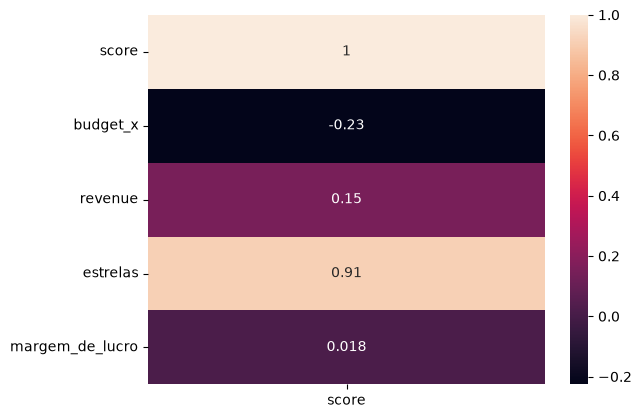

In [48]:
sns.heatmap(matriz_correlacao[['score']], annot=True)

<Axes: >

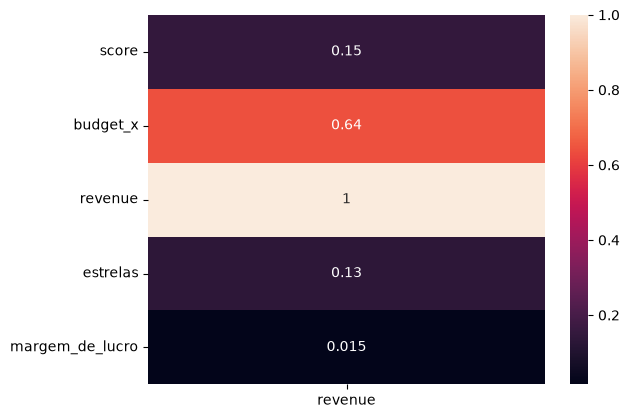

In [49]:
sns.heatmap(matriz_correlacao[['revenue']], annot=True)

<Axes: >

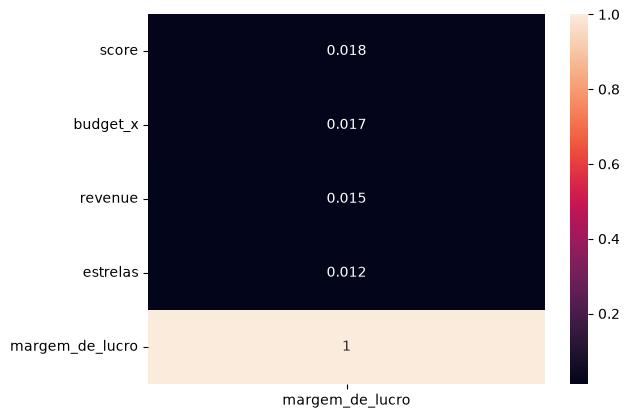

In [50]:
sns.heatmap(matriz_correlacao[['margem_de_lucro']], annot=True)

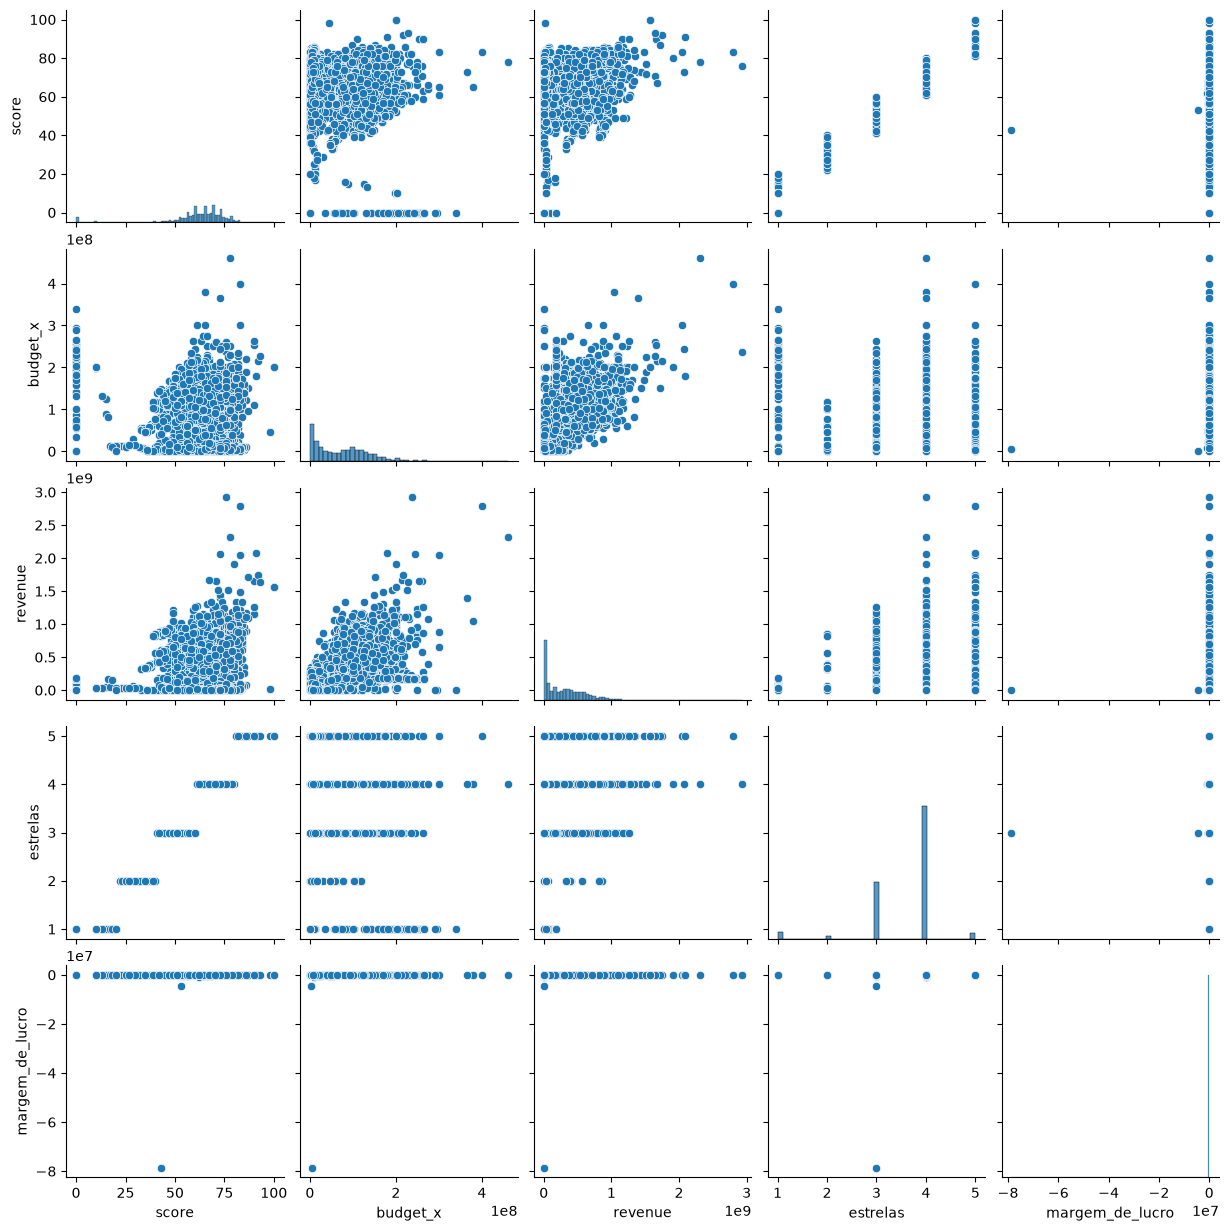

In [51]:
sns.pairplot(df)

In [52]:
generos = df['genre'].str.split(", ")

resumo = []
for g in generos:
    filtro = df[df['genre'].str.contains(g, na=False)]
    resumo.append({
        'Gênero': g,
        'Qtd Filmes': len(filtro),
        'Nota Média': filtro['rating'].mean(),
        'Faturamento Médio': filtro['gross'].mean()
    })

df_resumo = pd.DataFrame(resumo)
display(df_resumo)

TypeError: cannot use 'tuple' as a dict key (unhashable type: 'list')

In [65]:
df['genre']


0                                       Drama, Action
1                  Science Fiction, Adventure, Action
2       Animation, Adventure, Family, Fantasy, Comedy
3       Animation, Comedy, Family, Adventure, Fantasy
4                                              Action
                            ...                      
6155                                    Comedy, Drama
6156                                            Drama
6157            Action, Adventure, Fantasy, Animation
6158                                            Drama
6159                       Animation, Family, Fantasy
Name: genre, Length: 6160, dtype: str

In [67]:
generos_unicos = sorted(list({g.strip() for item in df['genre'].dropna() for g in item.split(',')}))

print(generos_unicos)

['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western']


In [ ]:
linguas_unicos = sorted(list({g.strip() for item in df['genre'].dropna() for g in item.split(',')}))

print(generos_unicos)

In [ ]:
resumo = []
for g in generos_unicos:
    filtro = df[df['genre'].str.contains(g, na=False)]
    resumo.append({
        'Gênero': g,
        'Qtd Filmes': len(filtro),
        'Nota Média': filtro['score'].median(),
        'Orçamento Médio': filtro['revenue'].median(),
        'Lucro Médio': filtro['budget_x'].median(),
    })

df_resumo = pd.DataFrame(resumo)
display(df_resumo[])

,Gênero,Qtd Filmes,Nota Média,Orçamento Médio,Lucro Médio
0,Action,1678,64.0,202406214.5,71430000.0
1,Adventure,1049,67.0,268314513.0,90000000.0
2,Animation,967,70.0,394200421.4,97400000.0
3,Comedy,1658,65.0,229082080.5,72470000.0
4,Crime,683,64.0,100216295.0,41527862.6
5,Documentary,172,70.0,560963629.4,90100000.0
6,Drama,2244,67.0,147669851.5,50000000.0
7,Family,824,68.0,349379315.4,93990000.0
8,Fantasy,831,67.0,291339353.2,89000000.0
9,History,250,70.0,72188697.5,43360000.0
